# 🐖 EfficientNet 모델 성능 비교 (Baseline vs Improved)
이 노트북은 기존 베이스라인 EfficientNet 모델과 3가지 개선사항(Letterbox Resizing, CoarseDropout 강화, RGBE 4채널 구조)이 적용된 EfficientNetV2-S 모델의 성능을 비교하기 위해 자동 생성되었습니다.


In [2]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
import albumentations as A
import cv2
import timm

import warnings
warnings.filterwarnings('ignore')

# 폰트 설정 (한글 깨짐 방지)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

c:\Users\ASUS\anaconda3\envs\ds_study\lib\site-packages\albumentations\__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## 1. 평가 데이터 및 경로 설정
베이스라인 모델 파일 파라미터와 개선된 모델 파일 파라미터가 보관된 경로를 지정합니다.
기존 모델 파일명은 현재 폴더에 있는 이름에 맞게 직접 수정해 주세요.


In [3]:
BASE_DIR = r"C:\Users\ASUS\Desktop\[ZB]멘토링_프로젝트\Kaggle\Pig_Posture_Recognition"
DATA_DIR = os.path.join(BASE_DIR, "data") 
OUTPUT_DIR = os.path.join(BASE_DIR, "output")

# [필수 수정] 기존 베이스라인 학습 모델의 파일 이름을 맞춰주세요.
BASELINE_MODEL_PATH = os.path.join(BASE_DIR, "baseline_efficientnet.pth") # 예: "baseline_efficientnet_b0.pth"

# 개선된 모델 경로
IMPROVED_MODEL_PATH = os.path.join(OUTPUT_DIR, "improved_method1_efficientnetv2.pth")

print(f"기존 모델 경로: {os.path.exists(BASELINE_MODEL_PATH)} ({BASELINE_MODEL_PATH})")
print(f"개선 모델 경로: {os.path.exists(IMPROVED_MODEL_PATH)} ({IMPROVED_MODEL_PATH})")

기존 모델 경로: False (C:\Users\ASUS\Desktop\[ZB]멘토링_프로젝트\Kaggle\Pig_Posture_Recognition\baseline_efficientnet.pth)
개선 모델 경로: True (C:\Users\ASUS\Desktop\[ZB]멘토링_프로젝트\Kaggle\Pig_Posture_Recognition\output\improved_method1_efficientnetv2.pth)


## 2. 성능 지표(Metric) 시각화 비교
이미 학습 과정에서 Valid F1 Score 등 결과를 기록해두셨다면, 모델을 직접 추론하지 않고도 아래의 그래프를 통해 즉시 성능 비교를 할 수 있습니다. 
`(baseline_valid_f1, improved_valid_f1 의 값을 실제 얻으신 점수로 변경해주세요)`


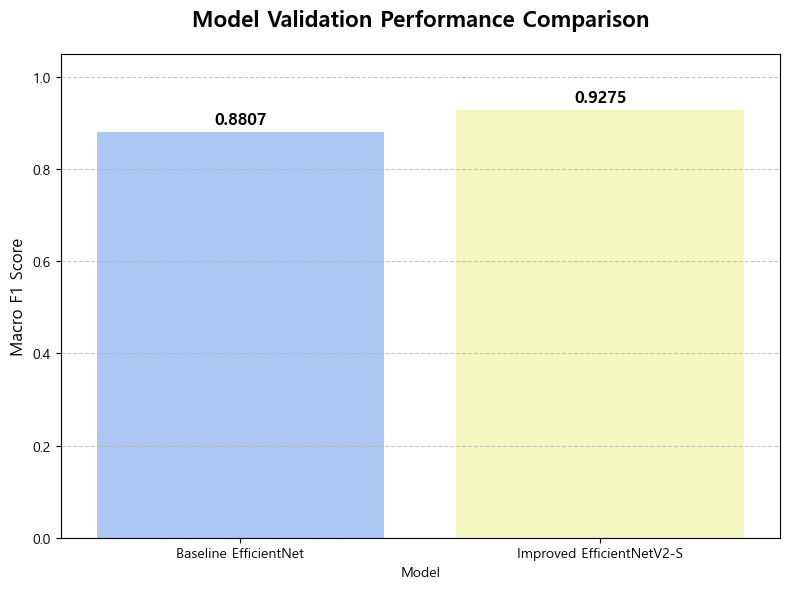

In [4]:
# ----------------------------------------------------
# 📌 여기에 실제 학습에서 얻었던 최고 Valid F1 Score를 입력하세요
# ----------------------------------------------------
baseline_valid_f1 = 0.8807  # <--- 기존 모델 점수로 변경
improved_valid_f1 = 0.9275  # <--- 향상된 모델 점수로 변경 (method1_analysis.png 참고)

metrics = pd.DataFrame({
    'Model': ['Baseline EfficientNet', 'Improved EfficientNetV2-S'],
    'Macro F1 Score': [baseline_valid_f1, improved_valid_f1]
})

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Model', y='Macro F1 Score', data=metrics, palette=['#A0C4FF', '#FDFFB6'])

# 막대 위에 수치 표시
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontweight='bold', fontsize=12)

plt.title('Model Validation Performance Comparison', fontsize=16, fontweight='bold', pad=20)
plt.ylim(0, 1.05)
plt.ylabel('Macro F1 Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 3. (선택) 모델 직접 추론 및 Confusion Matrix 시각화
만약 검증 셋(Validation)이나 특정 테스트 이미지를 통해 모델의 예측 결과를 세부적으로 비교하고 싶으신 경우 사용할 수 있는 함수 형식을 마련해 두었습니다.


In [ ]:
def plot_custom_confusion_matrix(y_true, y_pred, classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes, annot_kws={"size": 12})
    plt.title(title, fontsize=15, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

# 사용 예시 (추후 Validation 데이터 추론 로직 적용 시 활성화):
# classes = ['Sitting', 'Standing', 'Lying'] # 실제 클래스명으로 변경
# y_true_baseline = [...] 
# y_pred_baseline = [...]
# plot_custom_confusion_matrix(y_true_baseline, y_pred_baseline, classes, title="Baseline EfficientNet - Confusion Matrix")
